# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('C:/Users/hites/Desktop/data-viz-class-material-master/data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


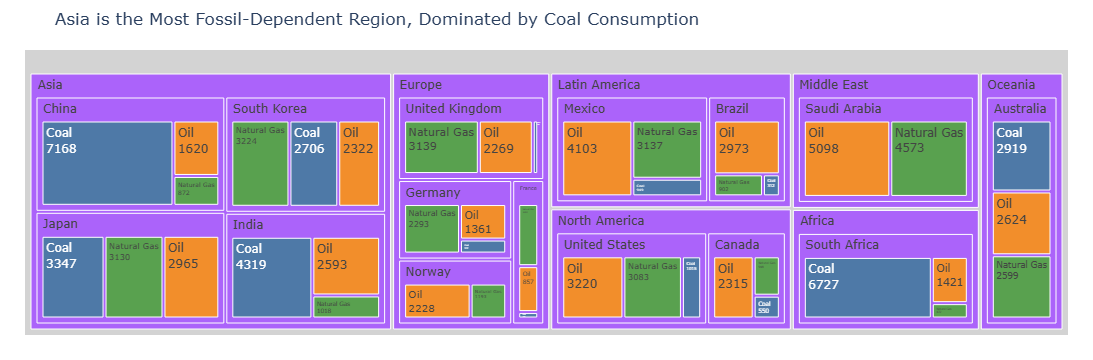

In [3]:
# Task 1
# YOUR CODE HERE

import plotly.express as px

# Step 1 — Filter only fossil fuels
df_fossil = df.loc[df['Source_Type'] == 'Fossil']

# Step 2 — Create treemap
fig = px.treemap(
    df_fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#4E79A7',          # CVD-safe blue
        'Oil': '#F28E2B',           # CVD-safe orange
        'Natural Gas': '#59A14F'    # CVD-safe green
    }
)

# Step 3 — Show TWh values only (no percentages)
fig.update_traces(
    textinfo="label+value"
)

# Step 4 — Grey out parent nodes (Region & Country)
fig.update_traces(
    marker=dict(colorscale=None),
    root_color="lightgrey"
)


fig.update_layout(
    title="Asia is the Most Fossil-Dependent Region, Dominated by Coal Consumption",
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()

## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


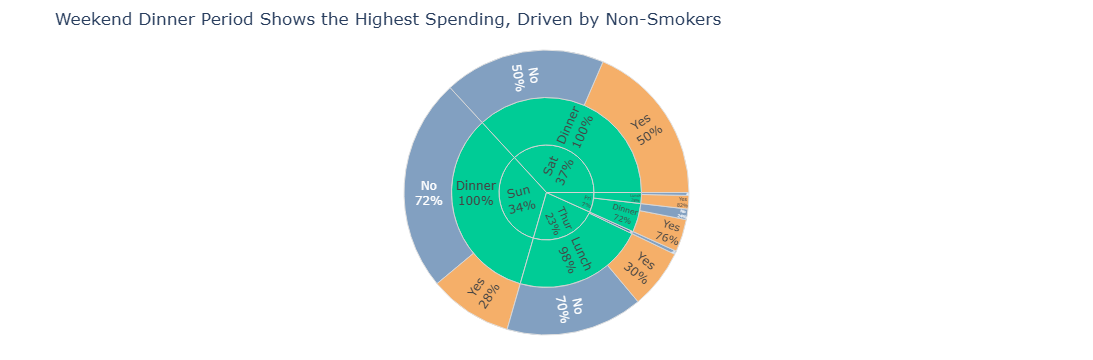

In [5]:
# Task 2
# YOUR CODE HERE

import plotly.express as px


tips = px.data.tips()


df_tips = tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()


fig = px.sunburst(
    df_tips,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#F28E2B',   # CVD-safe orange
        'No': '#4E79A7'     # CVD-safe blue
    }
)


fig.update_traces(
    textinfo='label+percent parent'
)


fig.update_traces(
    insidetextorientation='radial',
    marker=dict(line=dict(width=1, color="lightgrey"))
)


fig.update_layout(
    title="Weekend Dinner Period Shows the Highest Spending, Driven by Non-Smokers",
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()

## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


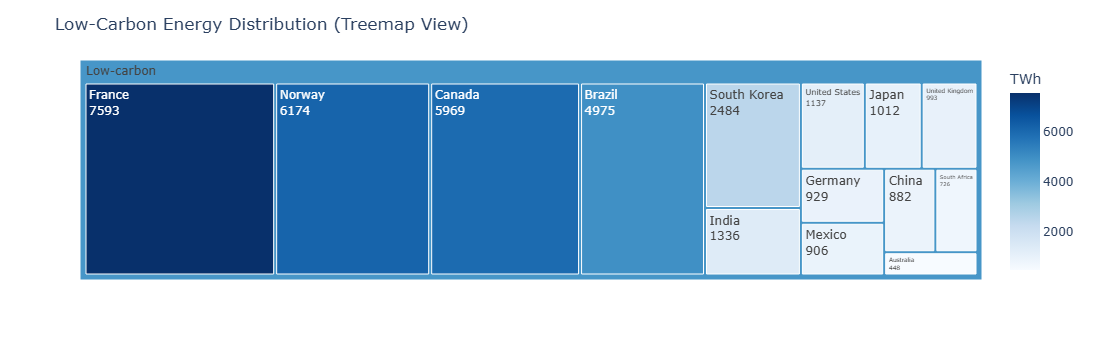

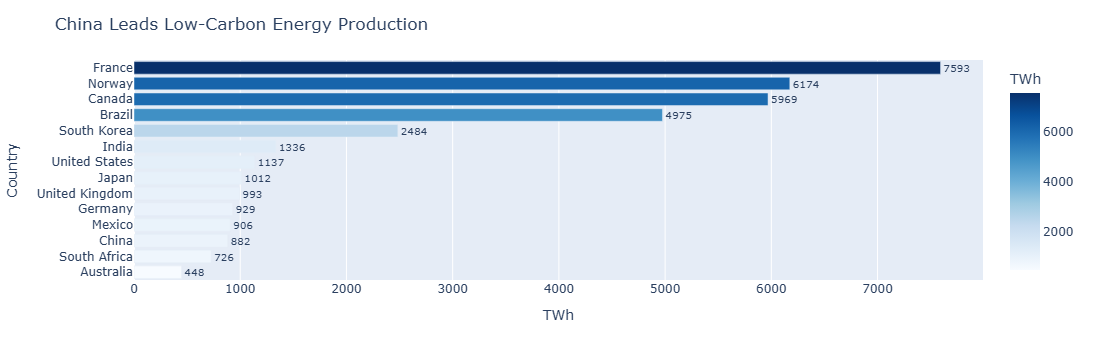

In [11]:
import plotly.express as px
import pandas as pd

df_low = df[df['Source_Type'] == 'Low-carbon']

df_country = df_low.groupby('Country', as_index=False)['TWh'].sum()

df_country['All'] = 'Low-carbon'

fig1 = px.treemap(
    df_country,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues'
)

fig1.update_traces(textinfo='label+value')

fig1.update_layout(
    title="Low-Carbon Energy Distribution (Treemap View)"
)

fig1.show()


df_sorted = df_country.sort_values('TWh', ascending=True)

fig2 = px.bar(
    df_sorted,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues'
)

fig2.update_traces(texttemplate='%{x:.0f}', textposition='outside')

fig2.update_layout(
    title="China Leads Low-Carbon Energy Production",
    xaxis_title="TWh",
    yaxis_title="Country"
)

fig2.show()